# INTRODUCCION

# Preparación de los datos

Importamos nuestras librerías y cargamos el dataset `gym_churn_us.csv`

In [2]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
gym = pd.read_csv("datasets/gym_churn_us.csv")

# Exploración de los datos

In [4]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [5]:
gym.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [6]:
gym.tail()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0
3999,1,0,1,0,0,12,1,30,178.861814,12.0,1,1.101832,1.035270,0


In [ ]:
gym.describe()

            gender  near_location      partner  promo_friends        phone  \
count  4000.000000    4000.000000  4000.000000    4000.000000  4000.000000   
mean      0.510250       0.845250     0.486750       0.308500     0.903500   
std       0.499957       0.361711     0.499887       0.461932     0.295313   
min       0.000000       0.000000     0.000000       0.000000     0.000000   
25%       0.000000       1.000000     0.000000       0.000000     1.000000   
50%       1.000000       1.000000     0.000000       0.000000     1.000000   
75%       1.000000       1.000000     1.000000       1.000000     1.000000   
max       1.000000       1.000000     1.000000       1.000000     1.000000   

       contract_period  group_visits          age  \
count      4000.000000   4000.000000  4000.000000   
mean          4.681250      0.412250    29.184250   
std           4.549706      0.492301     3.258367   
min           1.000000      0.000000    18.000000   
25%           1.000000      0.00

Nuestro Dataframe consta de 14 columnas y 4000 filas. No hay valores nulos

Hace falta estandarizar los nombres de las columnas a formato *snake_case*

In [9]:
gym.columns = gym.columns.str.lower()

gym.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

A continuación agruparemos nuestros datos por la columna `churn` y observaremos el comportamiento promedio de los usuarios que cancelan y los que no

In [10]:
gym_mean = gym.groupby("churn").mean()

print(gym_mean)

         gender  near_location   partner  promo_friends     phone  \
churn                                                               
0      0.510037       0.873086  0.534195       0.353522  0.903709   
1      0.510839       0.768143  0.355325       0.183789  0.902922   

       contract_period  group_visits        age  avg_additional_charges_total  \
churn                                                                           
0             5.747193      0.464103  29.976523                    158.445715   
1             1.728558      0.268615  26.989632                    115.082899   

       month_to_end_contract  lifetime  avg_class_frequency_total  \
churn                                                               
0                   5.283089  4.711807                   2.024876   
1                   1.662582  0.990575                   1.474995   

       avg_class_frequency_current_month  
churn                                     
0                               2.0


*   **Compromiso y Duración del Contrato (`contract_period`):** Los usuarios que cancelan muestran un compromiso a muy corto plazo, con contratos que promedian apenas **1.7 meses** (en su mayoría planes mensuales). Por el contrario, los clientes retenidos promedian contratos de **5.7 meses** (planes semestrales o anuales).
*   **Falta de Lazos y Descuentos (`partner` y `promo_friends`):** Existe una relación directa entre los incentivos y la retención. Solo el **35.5%** de los clientes que se van tienen convenios con empresas asociadas (vs. **53.4%** de los leales) y apenas un **18.3%** llegó por la promoción de un amigo (vs. **35.3%** de los leales). Los lazos corporativos y sociales reducen la deserción.
*   **Periodo Crítico de Fuga (`lifetime`):** La deserción ocurre de forma inmediata. El tiempo de vida promedio de los usuarios que cancelan es de apenas **0.99 meses** (su primer mes), lo que indica que el gimnasio no logra engancharlos tras su inscripción inicial.
*   **Asistencia y Uso del Servicio (`avg_class_frequency_current_month`):** La frecuencia de visitas semanales cae a la mitad durante el mes de cancelación (pasando de **2.0** visitas a **1.0** en promedio). La baja asistencia en el mes en curso es el indicador de alerta más evidente de un cliente en riesgo.
*   **Gasto en Servicios Adicionales (`avg_additional_charges_total`):** Se observa que el grupo que cancela mantiene un promedio de gasto de **115.08**, comparado con los **158.44** del grupo leal. Si bien esto sugiere a primera vista un buen flujo de ventas en la cafetería o tienda del gimnasio, **esta métrica requiere validación visual mediante histogramas**. Es necesario comprobar si este promedio está inflado por unos pocos usuarios atípicos (gastadores extremos) o si refleja un comportamiento generalizado de consumo antes de basar una estrategia en ello.

Observemos la distribución de nuestros datos:

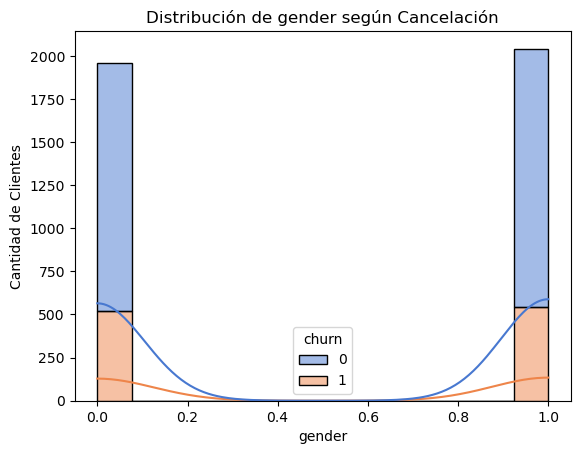

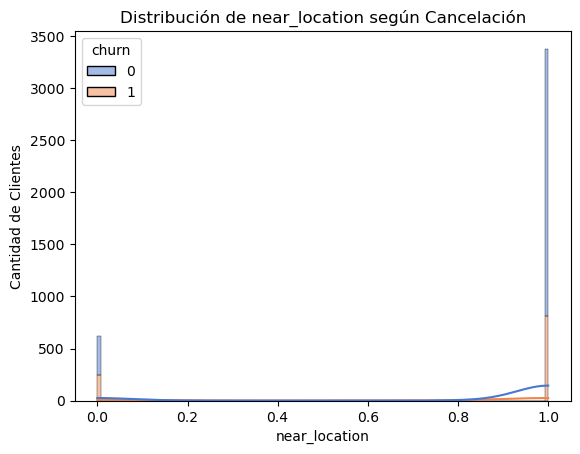

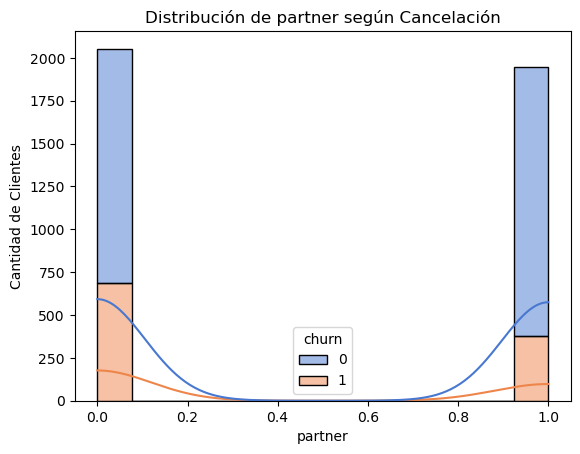

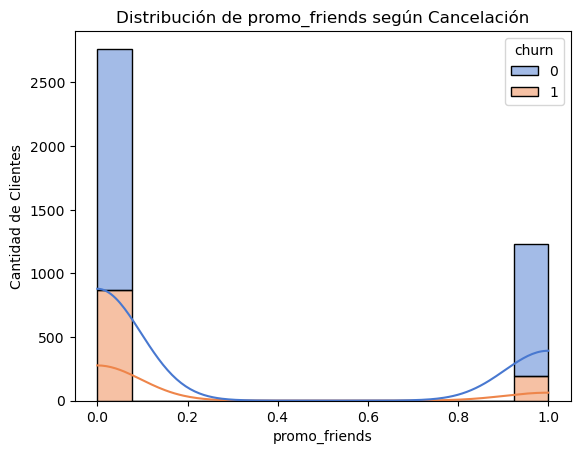

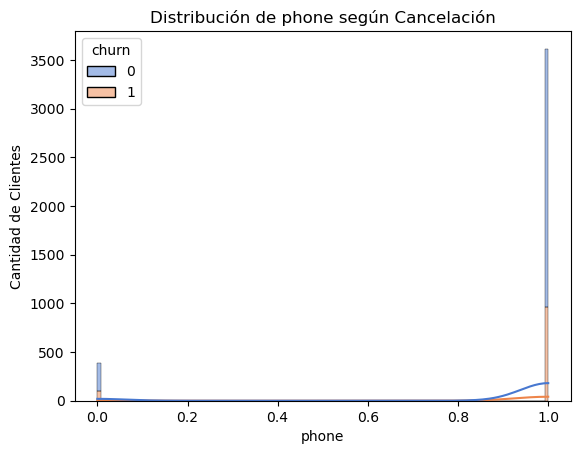

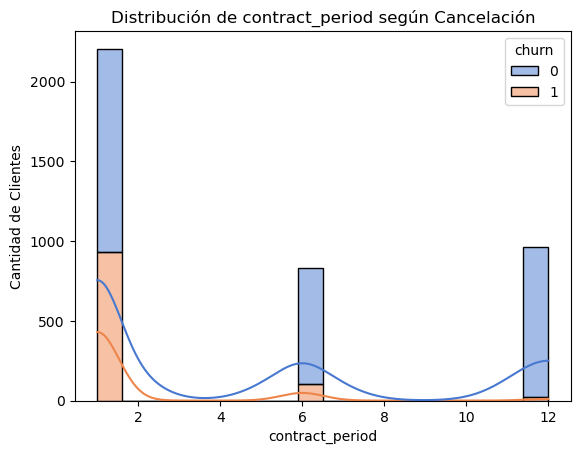

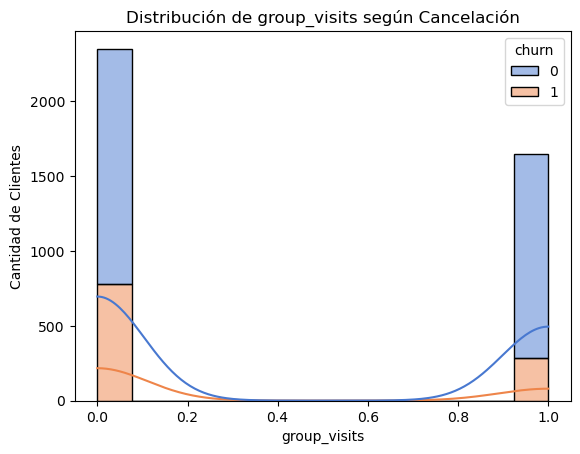

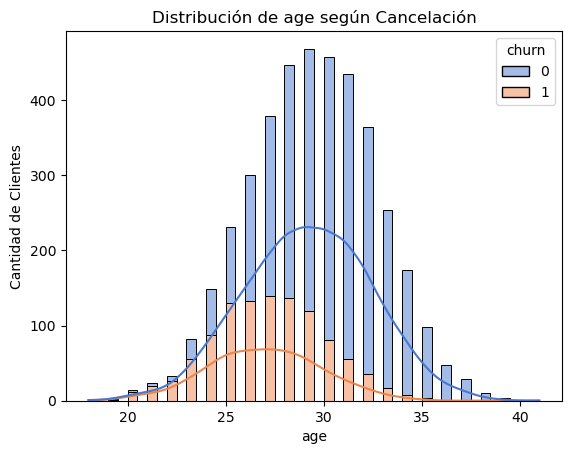

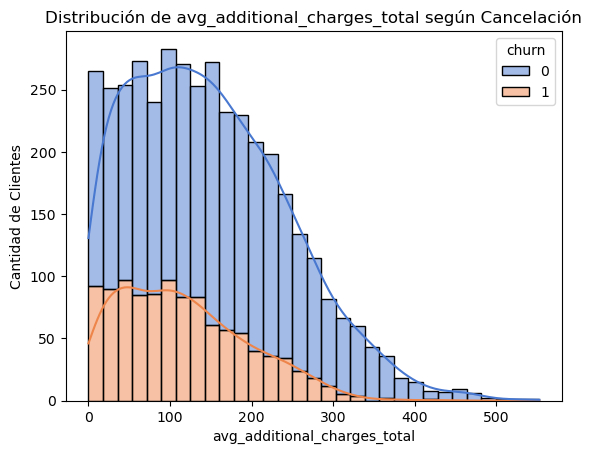

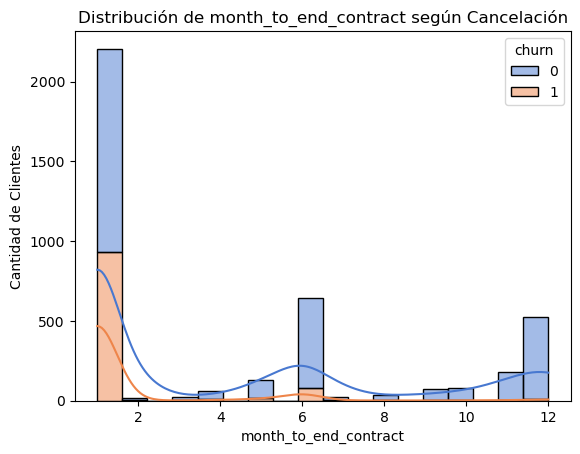

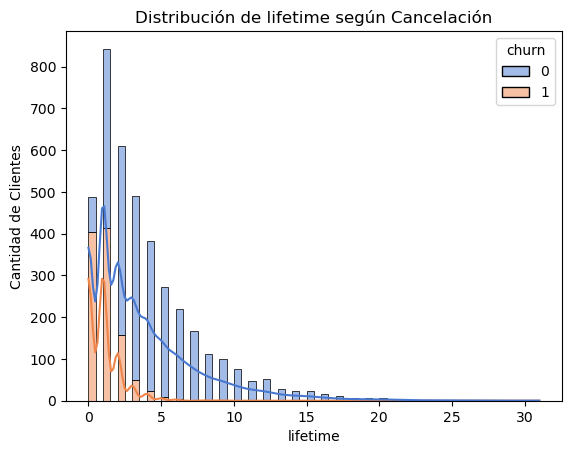

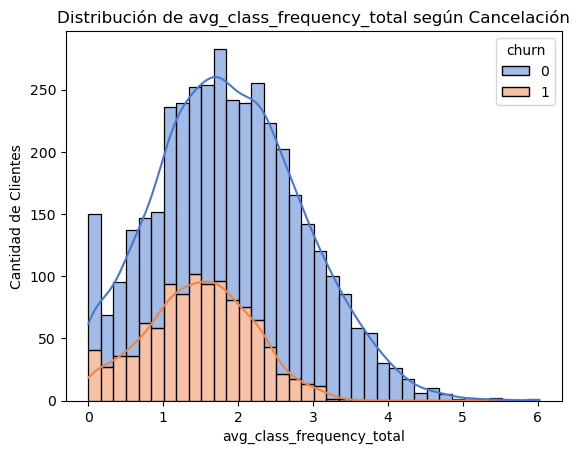

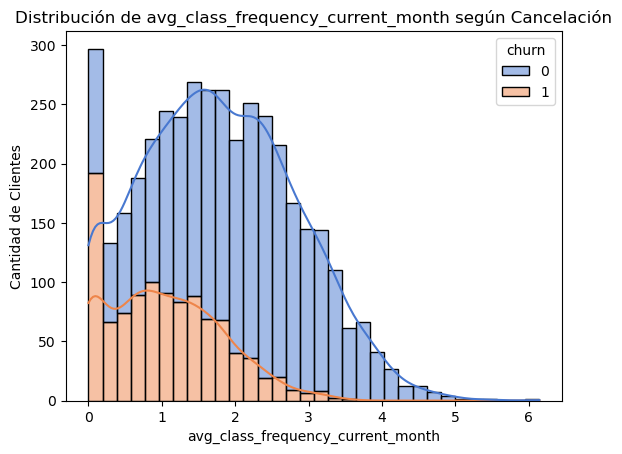

In [12]:
for i in gym.drop("churn", axis=1).columns:
    sns.histplot(data=gym, x=i, hue="churn", kde=True, multiple="stack", palette="muted")
    plt.title(f'Distribución de {i} según Cancelación')
    plt.xlabel(i)
    plt.ylabel('Cantidad de Clientes')
    plt.show()